# Diversified Transportation Problem

**Inspiration-Q**

---

## Content

* The transportation problem

* Modeling the problem as QUDO

* Solving the transportation problem with iQ-Xtreme

* Visualizing Solution

In [1]:
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

warnings.filterwarnings("ignore", category=RuntimeWarning)

import iq.api.iqrestapi
import iq.optim.qudo

In [2]:
iq.api.iqrestapi.initialize_credentials("YOUR_API_KEY")

## A transportation problem

Imagine that you have $N$ points (e.g. factories) that need to get supplied from $M$ supply
points (warehouses, mines, other factories). We consider that each factory $i=1,\dots,N$ has a
demand $D_i$ of a certain number of items, and each supply point $j=1,\dots,M$ has a total amount
$S_j$ of those items.

Furthermore, we will also assume that demand, supply and transported goods come in discrete
units.

Now, we want to have goods that are transported from the $M$ supply points to the $N$ factories.
We assume that the cost of transportation from a particular supply point $i$ to a given
destination point $j$ has a cost $C_{ij}$ which depends, for example, on the distance between $i$
and $j$.

The transportation problem consists in finding the amount $x_{ij}$ of units transported from
supply point $i$ to point $j$ that minimizes the cost function:

$$ E_C = \sum_{i,j} C_{ij} x_{ij}$$

Note that $x_{i,j}$ is a set of $M \times N$ non-negative integer variables, since we have
assumed that items are transported in discrete units.

Additionally, we must fulfill the following constraints.

* $\sum_{i = 1, \dots, M} x_{i j} = D_j $

* $\sum_{j = 1 \dots,  N} x_{i j} = S_i $

which requires that $\sum_i S_i = \sum_j D_j$. The more general case $\sum_i S_i \geq \sum_j D_j$
is also possible, but it involves introducing a slack variable to account for the extra demmand.
The optimization problem would be solved along the same lines in this case.


In the above picture we exemplify the original transportation problem (left) and the addition of
the "reservoir" demand point and slack variables (right).


#### Supply diversification

In many situations it may be beneficial not to overload the transportations routes, for example
in cases in which transportation tends to concentrate a lot at certain nodes.

To avoid this we can include a parameter, $\Delta$, with a value between 0 and 1, that allows to
diversify the supply points that arrive at each of the demmand points. $\Delta = 0$ is no
diversification, and it just finds the minimum cost solution.
$\Delta = 1$ is the maximum diversification allowed by our model.

Mathematically, we introduce this parameter as an extra term in the cost function,
$$
E_c = \Delta \sum_{i,j} (x_{ij})^2
$$
so as to penalize routes $x_{ij}$ from taking too large values.

One has to be careful tha this term does not interfere too much with quadratic terms imposing the
total supply/demmand constraints. In any case, $\Delta$ is a hyperparameter that should be tuned
for each particular application.

## Modelling the problem as QUDO

Let us consider a particular example with supply/demmand vectors.

In [3]:
S = np.array([1, 2, 5, 3])
D = np.array([4, 3, 4])
M = len(S)
N = len(D)

We assume that they are at positions on a plane, given by the arrays of vectors XS, XD

In [4]:
XS = np.array([[-1.0, -6.0], [-5.0, -8.0], [7.0, 1.0], [5.0, -1.0]])
XD = np.array([[12.0, 25.0], [-10.0, -2.0], [3.0, 1.0]])

We define the cost matrix as the matrix of distances between supply and demmand points:

In [5]:
C = np.linalg.norm(XS[:, np.newaxis] - XD[np.newaxis], axis=-1)
print(C)

[[33.61547263  9.8488578   8.06225775]
 [37.12142239  7.81024968 12.04159458]
 [24.51530134 17.2626765   4.        ]
 [26.92582404 15.03329638  2.82842712]]


It is convenient to normalize $C$ so that the average matrix element is smaller than one (this
will help us choose values for the Lagrange multipliers).

In [6]:
C = 0.1 * C / np.sqrt(np.trace(C @ C.T) / (N * M))

## QUDO problems

**Quadratic Unconstrained Digital Optimization (QUDO)** is the integer-variable generalization
of QUBO (Quadratic Unconstrained Binary Optimization). While QUBO variables are restricted to
$x_i \in \{0, 1\}$, QUDO variables take values in a finite set of integers
$x_i \in \{n_{\min}, \dots, n_{\max}\}$. The objective function has the same quadratic form,

$$
E = \frac{1}{2} \mathbf{x}^T Q\, \mathbf{x} + \mathbf{b}^T \mathbf{x}
$$

where $Q$ is a symmetric matrix and $\mathbf{b}$ is a vector of linear coefficients.
Constraints are incorporated by adding quadratic penalty terms to $E$, weighted by Lagrange
multipliers, so the problem remains unconstrained at the solver level.

## Translating the problem into QUDO language

We need to translate the problem into QUDO format. For this we express the constraints in terms
of two penalty terms with Lagrange multipliers $\lambda_S$ and $\lambda_D$. The cost function,
including transportation cost and the diversification term becomes

$$
E_c = \sum_{i,j} C_{ij} x_{ij} +
\lambda_S \sum_j \left( \sum_i x_{ij} - D_j \right)^2
+ \lambda_D \sum_i \left( \sum_j x_{ij} - S_i \right)^2
+ \Delta \sum_{i,j} (x_{ij})^2
$$

After a few algebraic manipulations, we need to express the cost function in terms of the
matrices $Q_c$ and the vector $b_c$,

$$
E_c = \frac{1}{2} \sum_{ij;kl} x_{ij} Q_{ij;kl} x_{kl} + \sum_{ij} b_{ij} x_{ij}
$$



We set now the Lagrange multipliers and the diversification value

In [7]:
lambda_D = 1
lambda_S = 1

# no diversification
Delta = 0

In [8]:
def build_qudo_problem(S, D, C, lambda_S=1.0, lambda_D=1.0, Delta=0.0):
    """Build the QUDO matrix Q and vector b for the transportation problem.

    Encodes transportation costs, supply/demand constraints, and a diversification
    penalty into the standard QUDO form: E = (1/2) x^T Q x + b^T x,
    where x is the flattened M*N flow matrix indexed as x[i*N + j].

    Parameters
    ----------
    S : ndarray of shape (M,)
        Supply amounts at each source node.
    D : ndarray of shape (N,)
        Demand amounts at each destination node.
    C : ndarray of shape (M, N)
        Normalized transport cost from source i to destination j.
    lambda_S : float
        Lagrange multiplier for supply constraints.
    lambda_D : float
        Lagrange multiplier for demand constraints.
    Delta : float
        Diversification penalty in [0, 1]. 0 = minimize cost only.

    Returns
    -------
    Q : ndarray of shape (M*N, M*N)
        Quadratic coefficient matrix.
    b : ndarray of shape (M*N,)
        Linear coefficient vector.
    """
    M, N = len(S), len(D)
    dim = M * N
    Q = np.zeros((dim, dim))
    b = np.zeros(dim)

    # Supply constraints: penalize (sum_j x_{ij} - S_i)^2 for each source i
    for i in range(M):
        v = np.zeros(dim)
        v[i * N : (i + 1) * N] = 1
        Q += 2 * lambda_S * np.outer(v, v)
        b -= 2 * lambda_S * S[i] * v

    # Demand constraints: penalize (sum_i x_{ij} - D_j)^2 for each destination j
    for j in range(N):
        v = np.zeros(dim)
        v[j::N] = 1
        Q += 2 * lambda_D * np.outer(v, v)
        b -= 2 * lambda_D * D[j] * v

    b += C.ravel()
    Q += Delta * np.eye(dim)

    return Q, b


Q, b = build_qudo_problem(S, D, C, lambda_S=lambda_S, lambda_D=lambda_D, Delta=Delta)

## Solving the transportation problem with iQ-Xtreme

In [9]:
dim = M * N
nmin = np.zeros(dim, np.int32)
nmax = (max(S) + 2) * np.ones(dim, np.int32)

In [10]:
n_opt, obj_opt = iq.optim.qudo.solve_QUDO(matrix=Q, vector=b, min_n=nmin, max_n=nmax, steps=2000)
print("solution", n_opt)
print("cost function", obj_opt)

solution [1, 1, -1, 1, 1, 0, 1, 0, 4, 1, 1, 1]
cost function -79.16746958483878


In [11]:
def check_solution(n_opt, S, D, tol=1e-6):
    """Verify that the solution satisfies supply and demand constraints.

    Parameters
    ----------
    n_opt : ndarray of shape (M, N)
        Flow matrix where n_opt[i, j] is the amount transported from source i
        to destination j.
    S : ndarray of shape (M,)
        Required supply at each source node.
    D : ndarray of shape (N,)
        Required demand at each destination node.
    tol : float
        Tolerance for constraint violation.

    Returns
    -------
    bool
        True if all constraints are satisfied within tolerance.
    """
    demand_ok = np.linalg.norm(n_opt.sum(axis=0) - D) < tol
    supply_ok = np.linalg.norm(n_opt.sum(axis=1) - S) < tol
    satisfied = demand_ok and supply_ok
    print("constraints are satisfied" if satisfied else "constraints are *NOT* satisfied")
    return satisfied


n0 = np.reshape(np.asarray(n_opt), [M, N])
check_solution(n0, S, D)

cost = np.sum(n0 * C)
print("final cost is", cost)

constraints are satisfied
final cost is 0.8325304151612198


## Visualizing Solution

Finally we draw results

We will show supply nodes in green and demand nodes in orange.

In [12]:
def draw_results(S, D, XS, XD, n0):
    """Visualize the transportation solution as a directed graph.

    Supply nodes are shown in green and demand nodes in orange. Edges connect
    active routes (flow > 0) and are labeled with the transported amount.

    Parameters
    ----------
    S : ndarray of shape (M,)
        Supply amounts (determines number of source nodes).
    D : ndarray of shape (N,)
        Demand amounts (determines number of destination nodes).
    XS : ndarray of shape (M, 2)
        2D positions of supply nodes.
    XD : ndarray of shape (N, 2)
        2D positions of demand nodes.
    n0 : ndarray of shape (M, N)
        Flow matrix of transported amounts.
    """
    M, N = len(S), len(D)
    pos = {i: XS[i] for i in range(M)} | {M + j: XD[j] for j in range(N)}
    node_colors = {i: "green" for i in range(M)} | {M + j: "orange" for j in range(N)}
    node_labels = {i: i for i in range(M)} | {M + j: j for j in range(N)}

    G = nx.DiGraph()
    for i in range(M):
        for j in range(N):
            if n0[i, j] > 1e-5:
                G.add_edge(i, M + j)

    edge_labels = {(i, M + j): int(n0[i, j]) for i, j in np.argwhere(n0 > 1e-5)}

    fig, ax = plt.subplots(figsize=(6, 6))
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    nx.draw(G, pos, node_color=[node_colors[n] for n in G.nodes()], labels=node_labels, ax=ax)
    return

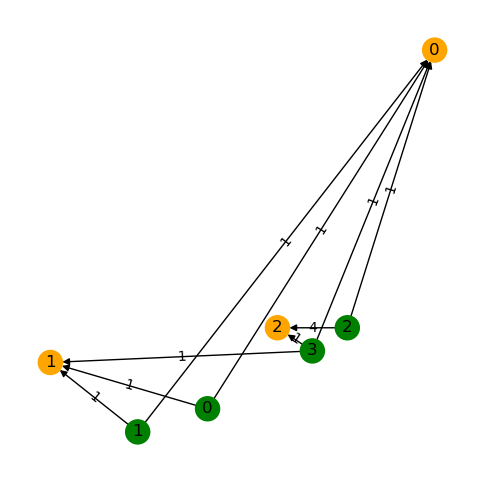

In [13]:
draw_results(S, D, XS, XD, n0)